<a href="https://colab.research.google.com/github/mariaaljafri/Exploratory-Data-Analysis-EDA-/blob/main/ARTI406_Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ARTI406 - Machine Learning

# Assignment 1: Exploratory Data Analysis (EDA)

EDA is the first and most important step in any Machine Learning project.
Before building models, we must understand:

- What does the data represent?
- Are there missing values?
- Are there outliers?
- What patterns exist?
- Which variables influence others?

If we do not understand the data, we cannot build a good model.

### Why EDA is Important

In real-world machine learning projects:

    1- 70–80% of the time is spent on understanding and cleaning data
    2- Only 20–30% is spent building models

**EDA helps us:**

- Detect errors
- Identify trends
- Discover relationships
- Make business decisions

![step1.png](attachment:step1.png)

In [25]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()

In [26]:
# Load Dataset
df = pd.read_csv('heart.csv')# Display first 5 rows. If you want to display all rows, use df.head(-1)
df.head(-1)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1019,47,1,0,112,204,0,1,143,0,0.1,2,0,2,1
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0


### Check Missing Values

In [27]:
# Check all values
print(df.isna())

        age    sex     cp  trestbps   chol    fbs  restecg  thalach  exang  \
0     False  False  False     False  False  False    False    False  False   
1     False  False  False     False  False  False    False    False  False   
2     False  False  False     False  False  False    False    False  False   
3     False  False  False     False  False  False    False    False  False   
4     False  False  False     False  False  False    False    False  False   
...     ...    ...    ...       ...    ...    ...      ...      ...    ...   
1020  False  False  False     False  False  False    False    False  False   
1021  False  False  False     False  False  False    False    False  False   
1022  False  False  False     False  False  False    False    False  False   
1023  False  False  False     False  False  False    False    False  False   
1024  False  False  False     False  False  False    False    False  False   

      oldpeak  slope     ca   thal  target  
0       False  Fal

In [28]:
print(df.isna().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


### Check duplicate rows

In [29]:
# checking duplicate rows
df.duplicated()[df.duplicated()==True]

,0
15,True
31,True
43,True
55,True
61,True
...,...
1020,True
1021,True
1022,True
1023,True


In [30]:
# Remove duplicate rows
df = df.drop_duplicates()

In [31]:
print(f"Number of rows after cleaning: {len(df)}")
print(f"Number of duplicates remaining: {df.duplicated().sum()}")

Number of rows after cleaning: 302
Number of duplicates remaining: 0


## Data Cleaning Steps

### Why cleaning was needed:
The Heart Disease dataset had 723 duplicate rows that needed to be removed. Duplicate data can bias analysis and give incorrect results.

### Cleaning steps performed:

1. **Loaded the dataset** - 1025 rows, 14 columns
2. **Checked for missing values** - None found (all columns complete)
3. **Checked for duplicates** - Found 723 duplicate rows
4. **Removed duplicates** - Used `df.drop_duplicates()`
5. **Verified data types** - All columns are numeric (int64/float64)

### Before vs After:

| Metric | Before | After |
|--------|--------|-------|
| Total rows | 1025 | 302 |
| Duplicate rows | 723 | 0 |
| Missing values | 0 | 0 |



 ## Before cleaning: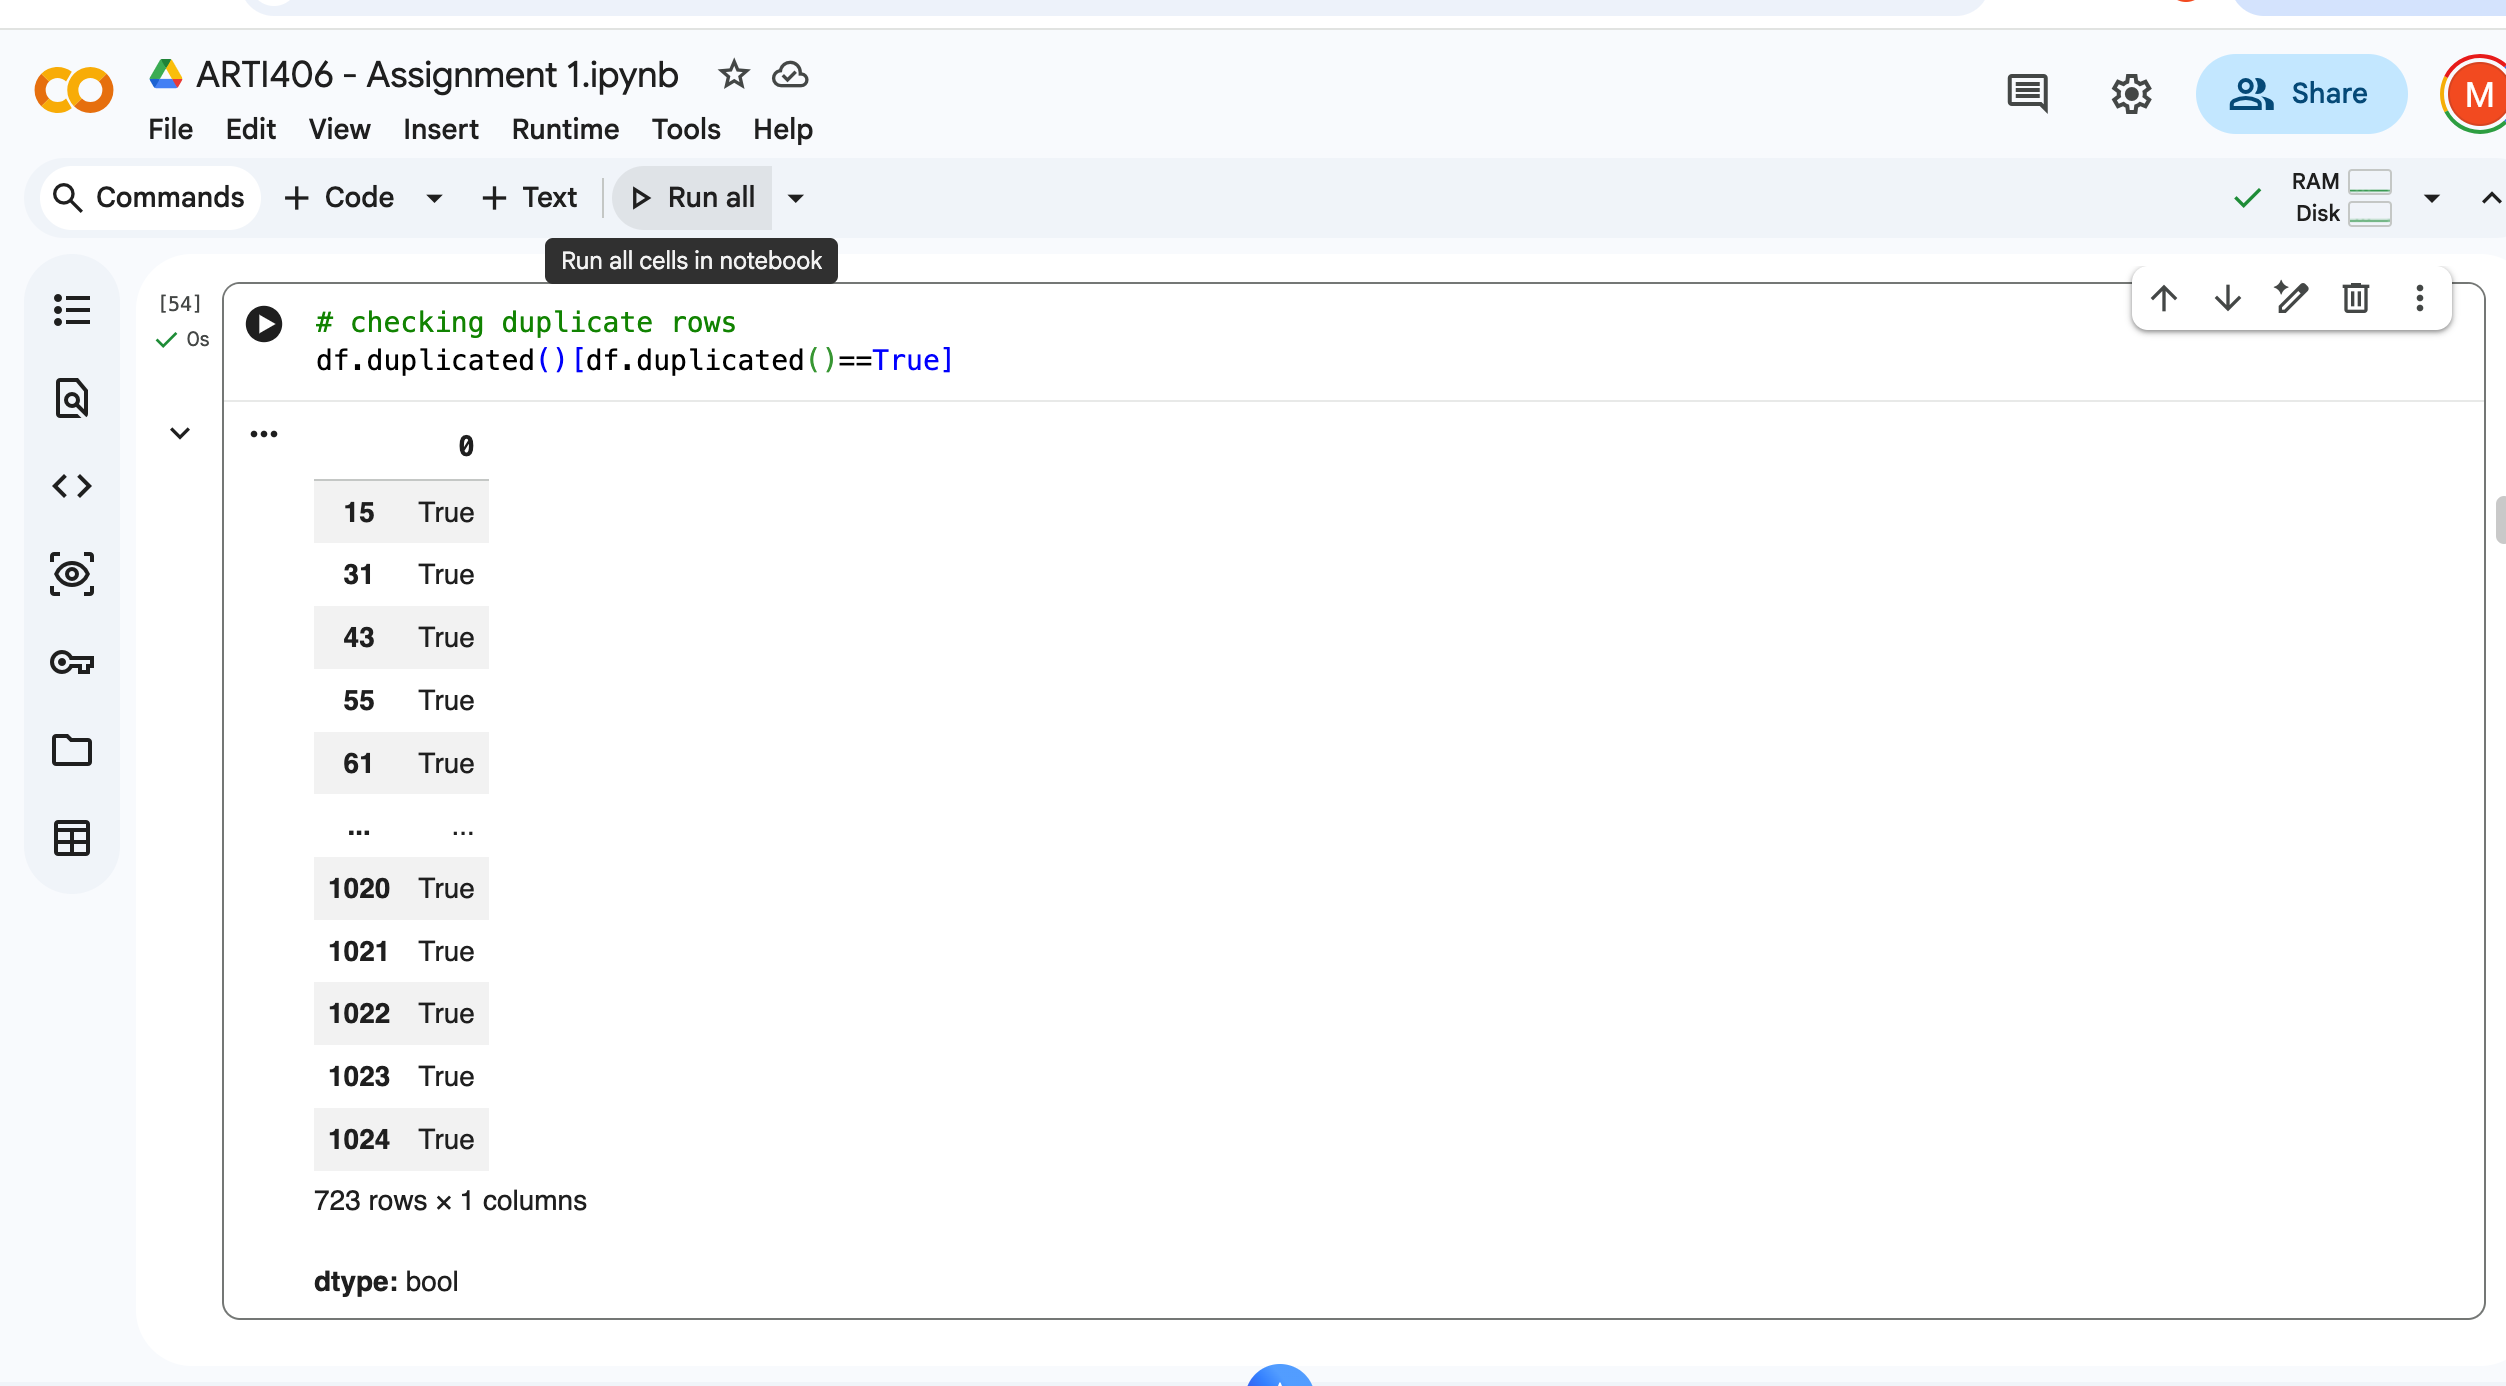

## After cleaning: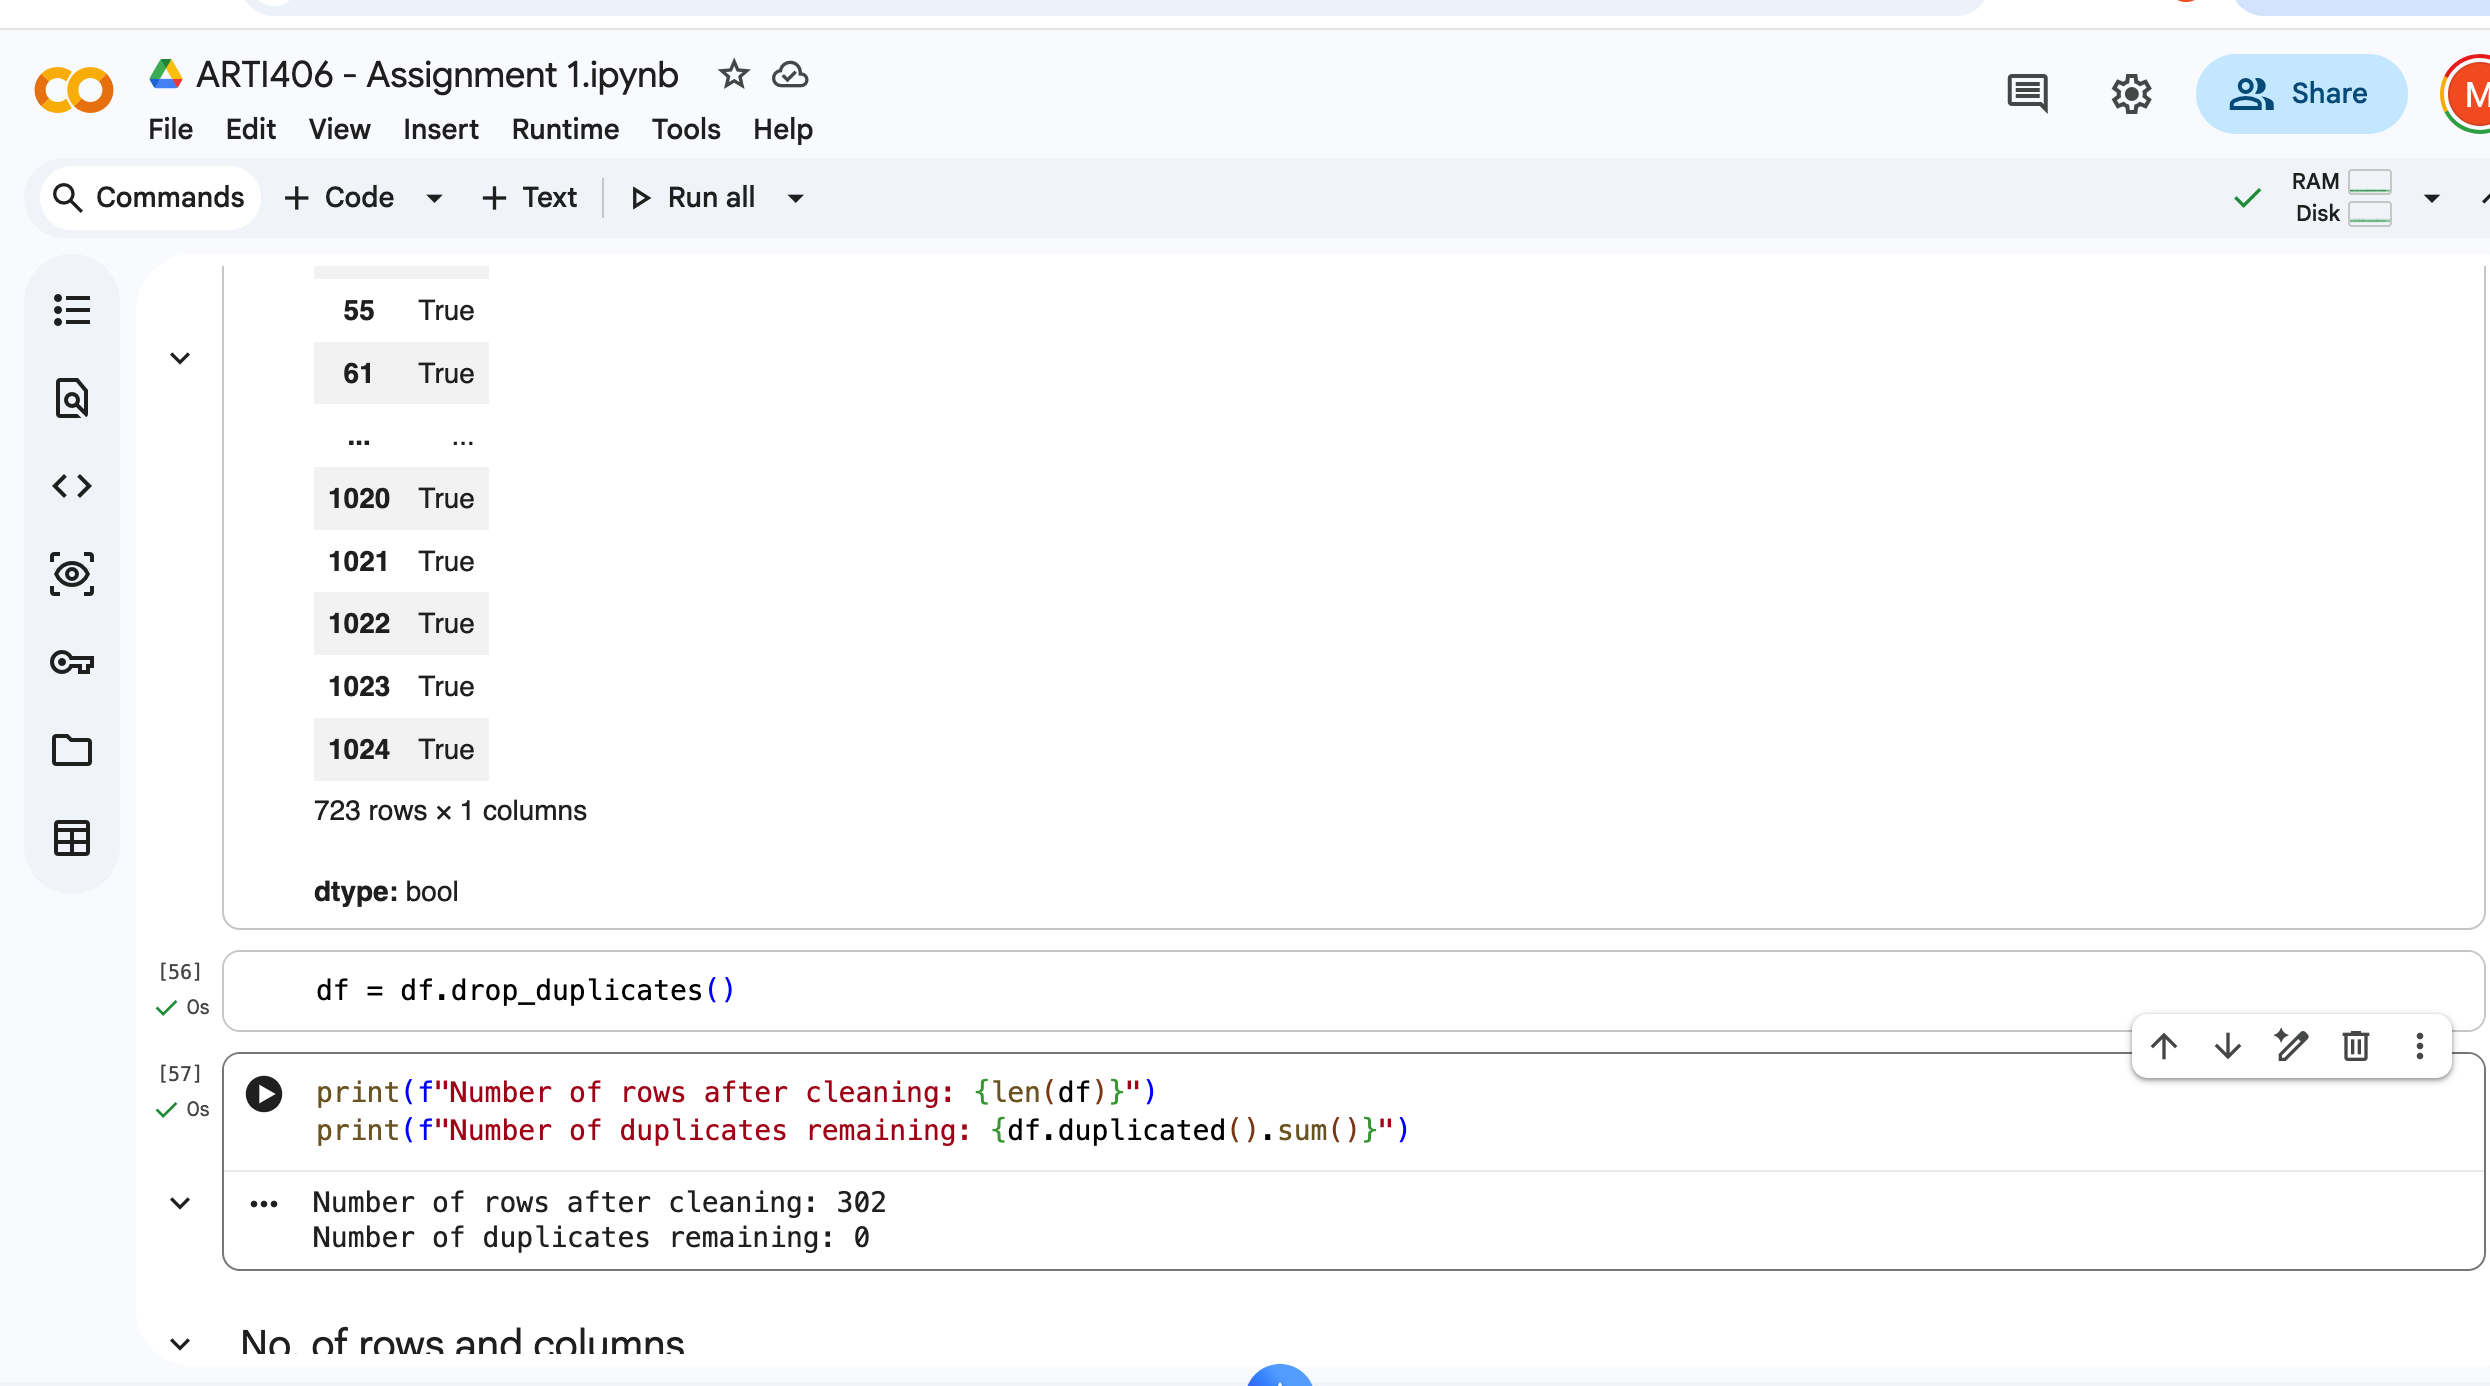

### No. of rows and columns

In [32]:
# finding number of rows and columns

print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (302, 14) 

number of rows:  302
number of columns:  14


### Data type of columns

In [33]:
# viewing the data types of columns
df.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [34]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [35]:
# Check data types (no conversion needed for heart disease dataset)
df.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [36]:
# Statistical summary
df.describe(include='all')

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### Univariate Analysis


### Chart 1: Age Distribution (Histogram)

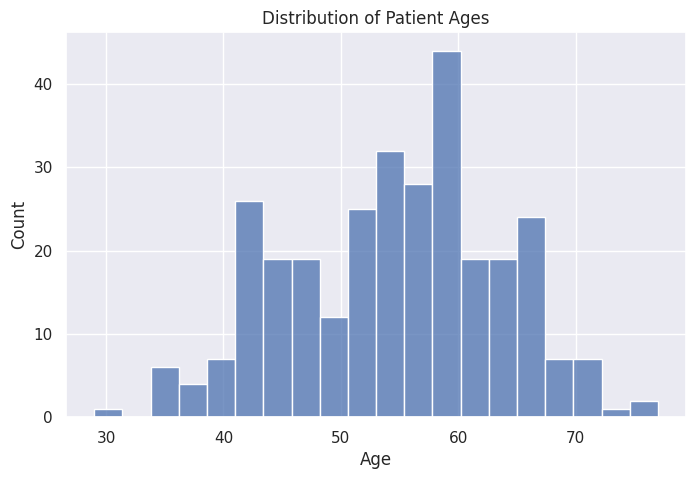

In [37]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=20,)
plt.title("Distribution of Patient Ages")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


**Why this chart?**  
To understand the age range of patients in the dataset.

**What do I see?**  
Most patients are between 50-60 years old. Very few patients are under 40 or over 70.

**Patterns/Trends:**  
The distribution is roughly bell-shaped, peaking around age 55.

**What can be learned?**  
Heart disease is more common in middle-aged adults (50-60 years) in this dataset.

### Chart 2: Heart Disease by Gender (Bar Chart)

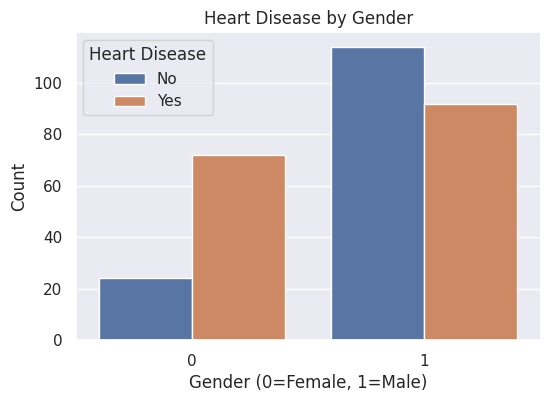

In [38]:
plt.figure(figsize=(6,4))
sns.countplot(x='sex', hue='target', data=df)
plt.title("Heart Disease by Gender")
plt.xlabel("Gender (0=Female, 1=Male)")
plt.ylabel("Count")
plt.legend(title="Heart Disease", labels=['No', 'Yes'])
plt.show()


**Why this chart?**  
To compare heart disease rates between males and females.

**What do I see?**  
More males have heart disease than females. The blue bars (disease) are higher for males.

**Patterns/Trends:**  
Both genders have more disease cases than no disease cases in this dataset.

**What can be learned?**  
Males may have a higher risk factor for heart disease.

### Chart 3: Age vs Maximum Heart Rate (Scatter Plot)

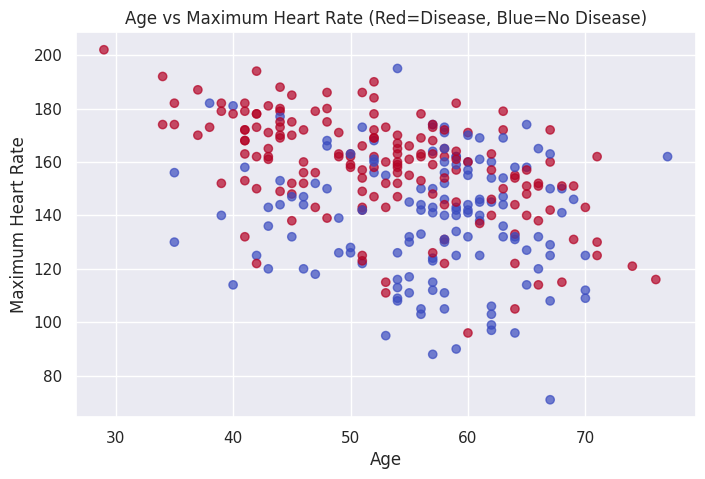

In [39]:
plt.figure(figsize=(8,5))
plt.scatter(df['age'], df['thalach'], c=df['target'], cmap='coolwarm', alpha=0.7)
plt.title("Age vs Maximum Heart Rate (Red=Disease, Blue=No Disease)")
plt.xlabel("Age")
plt.ylabel("Maximum Heart Rate")
plt.show()



**Why this chart?**  
To see the relationship between age, heart rate, and heart disease.

**What do I see?**  
Red dots (heart disease) tend to be lower on the chart. Orange dots (no disease) have higher heart rates.

**Patterns/Trends:**  
As age increases, maximum heart rate decreases for all patients.

**What can be learned?**  
Patients with heart disease have lower maximum heart rates compared to healthy patients of the same age.

### Chart 4: Cholesterol Levels by Heart Disease (Box Plot)

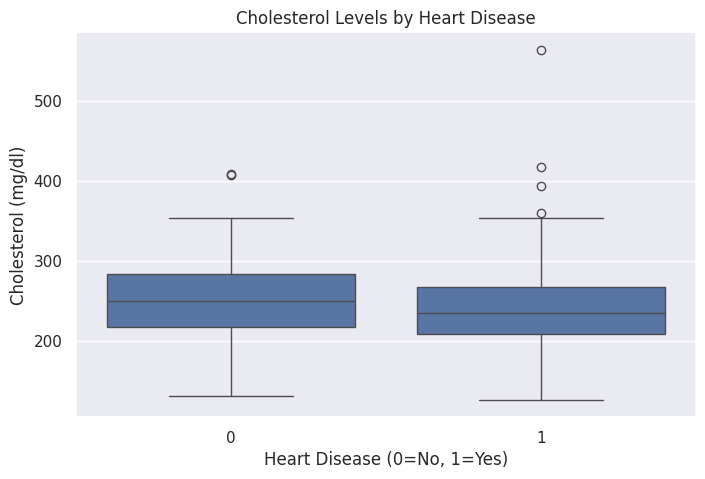

In [40]:
plt.figure(figsize=(8,5))
sns.boxplot(x='target', y='chol', data=df)
plt.title("Cholesterol Levels by Heart Disease")
plt.xlabel("Heart Disease (0=No, 1=Yes)")
plt.ylabel("Cholesterol (mg/dl)")
plt.show()


**Why this chart?**  
To compare cholesterol levels between patients with and without heart disease.

**What do I see?**  
Patients with heart disease (1) have slightly higher cholesterol levels than patients without (0).

**Patterns/Trends:**  
The box for disease patients is positioned higher on the chart.

**What can be learned?**  
High cholesterol may be a risk factor for heart disease.

### Chart 5: Heart Disease by Chest Pain Type (Bar Chart)

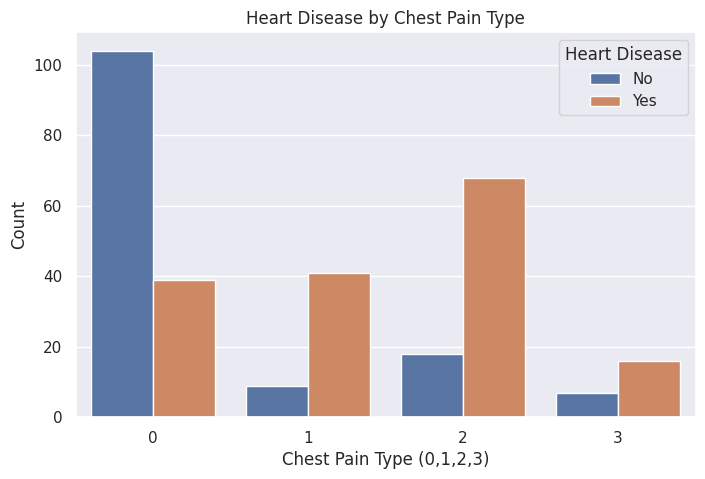

In [41]:
plt.figure(figsize=(8,5))
sns.countplot(x='cp', hue='target', data=df)
plt.title("Heart Disease by Chest Pain Type")
plt.xlabel("Chest Pain Type (0,1,2,3)")
plt.ylabel("Count")
plt.legend(title="Heart Disease", labels=['No', 'Yes'])
plt.show()



**Why this chart?**  
To see which chest pain types are most associated with heart disease.

**What do I see?**  
Chest pain type 0 has many disease cases. Chest pain type 1 has mostly no disease. Types 2 and 3 have mixed results.

**Patterns/Trends:**  
Different chest pain types show very different patterns of heart disease.

**What can be learned?**  
Chest pain type 0 is a strong indicator of heart disease risk.

### Chart 6: Resting Blood Pressure by Age (Line Plot)

/tmp/ipykernel_1986/3289046851.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='age', y='trestbps', hue='target', data=df, ci=None)


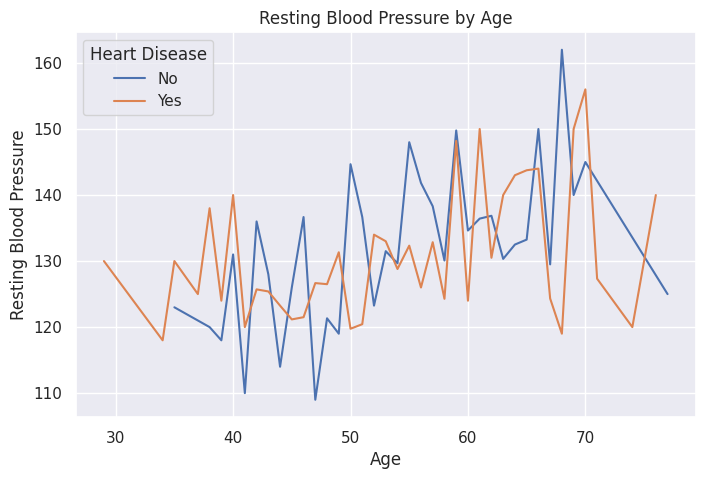

In [42]:
plt.figure(figsize=(8,5))
sns.lineplot(x='age', y='trestbps', hue='target', data=df, ci=None)
plt.title("Resting Blood Pressure by Age")
plt.xlabel("Age")
plt.ylabel("Resting Blood Pressure")
plt.legend(title="Heart Disease", labels=['No', 'Yes'])
plt.show()


**Why this chart?**  
To see how blood pressure changes with age for patients with and without heart disease.

**What do I see?**  
The red line (heart disease) stays higher than the blue line (no disease) at most ages.

**Patterns/Trends:**  
Blood pressure tends to increase with age for both groups.

**What can be learned?**  
Patients with heart disease generally have higher blood pressure across all ages.

### Chart 7: Average Cholesterol Level by Age (Line Chart)

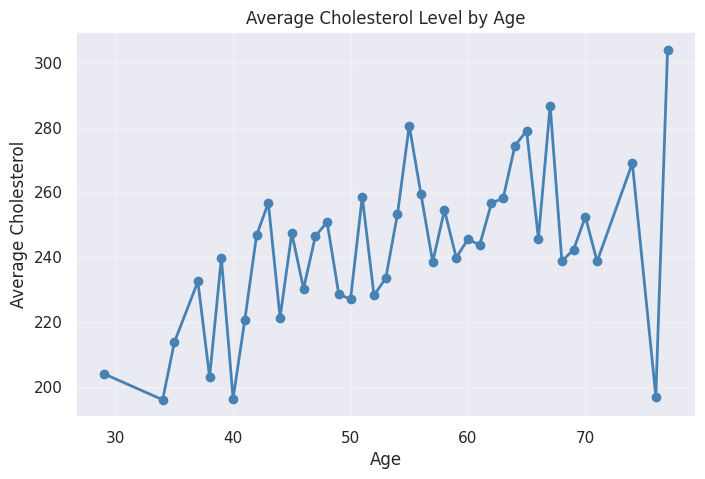

In [43]:
plt.figure(figsize=(8,5))
avg_chol_by_age = df.groupby('age')['chol'].mean()
plt.plot(avg_chol_by_age.index, avg_chol_by_age.values, marker='o', color='steelblue', linewidth=2)
plt.title("Average Cholesterol Level by Age")
plt.xlabel("Age")
plt.ylabel("Average Cholesterol")
plt.grid(True, alpha=0.3)
plt.show()



**Why this chart?**  
To see how cholesterol levels change as patients get older.

**What do I see?**  
Cholesterol levels increase with age, peaking around age 55-60.

**Patterns/Trends:**  
The line goes up and down but shows a general increase with age.

**What can be learned?**  
Older patients tend to have higher cholesterol levels, which may explain higher heart disease risk in older adults.

# Assignment

In this assignment, you will apply the EDA techniques learned in class to a dataset of your choice. You must submit the following to the assignment 1 folder.
1. Dataset file
2. Dataset Description readme file
2. Jupyter Notebook
